   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.0 MB/s eta 0:00:00
MULTIVARIATE GAUSSIAN HMM — NIFTY 50

FEATURES USED:
• Daily Return
• 20-Day Volatility
• 20-Day Momentum

REGIME STATISTICS
 State  Observations  Mean Return (%)  Annualized Volatility (%)  Mean Momentum (%)  Probability of State (%)
     1          1144           0.1028                     9.2415             1.1345                   42.5595
     0          1217          -0.0035                    14.4157             0.0660                   45.2753
     2           327           0.0289                    33.0303            -0.8920                   12.1652

TRANSITION MATRIX
         State 0  State 1  State 2
State 0   0.9696   0.0199   0.0105
State 1   0.0195   0.9798   0.0007
State 2   0.0411   0.0000   0.9589

CURRENT REGIME
----------------------------------------------------------------------
Date: 2025-12-31
Regime: Low Volatility

Current State Probabilities:
State 0: 0.02%
State 1: 99.98%
State 2:

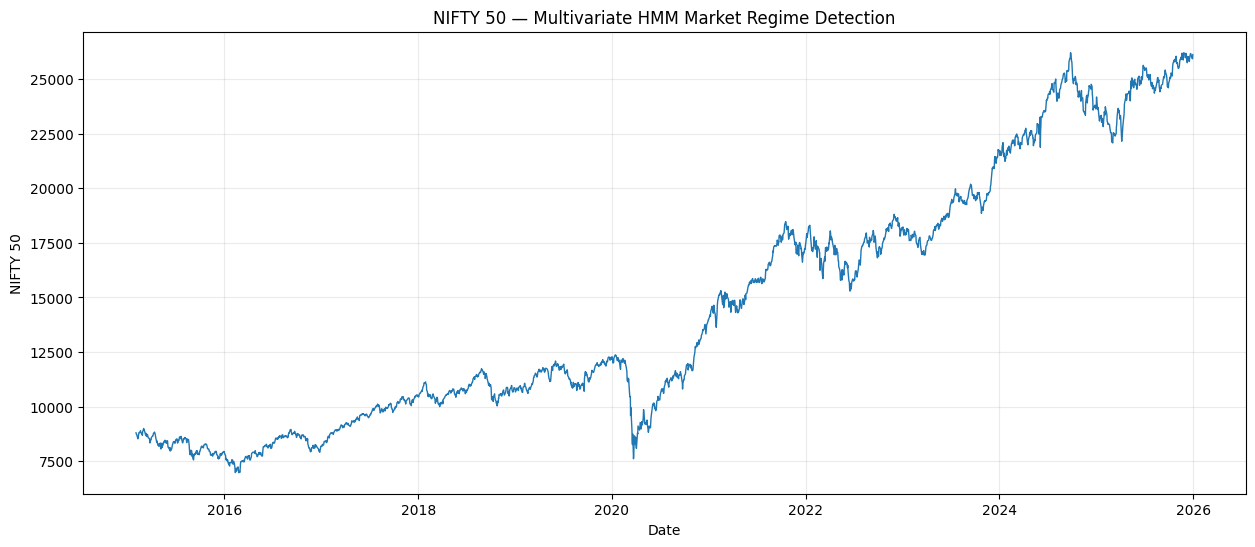

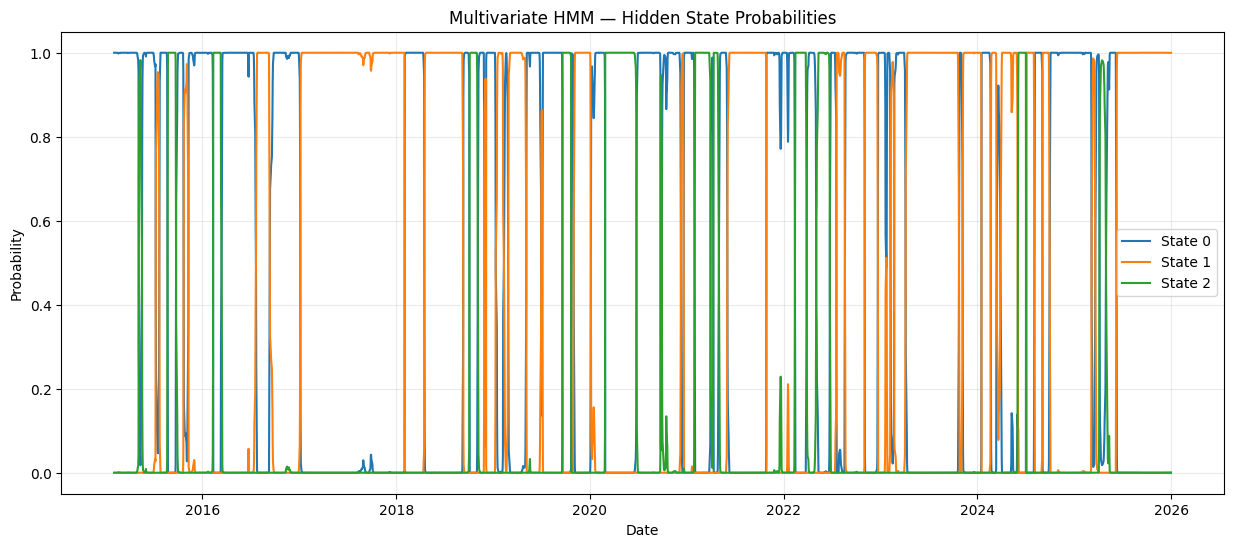


AVERAGE FEATURES BY REGIME
Price                Return  Volatility  Momentum
Regime                                           
High Volatility    0.000289    0.018098 -0.008920
Low Volatility     0.001028    0.005834  0.011345
Medium Volatility -0.000035    0.009219  0.000660

Saved:
NIFTY50_Multivariate_HMM_Regimes.csv


In [1]:
# ============================================================
# PROJECT 2 — MULTIVARIATE GAUSSIAN HMM
# NIFTY 50 MARKET REGIME DETECTION
# ============================================================

!pip -q install yfinance hmmlearn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# 1. DOWNLOAD NIFTY 50 DATA
# ------------------------------------------------------------
df = yf.download(
    "^NSEI",
    start="2015-01-01",
    end="2026-01-01",
    auto_adjust=True,
    progress=False
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df = df.dropna()

# ------------------------------------------------------------
# 2. CREATE MULTIVARIATE FEATURES
# ------------------------------------------------------------
df["Return"] = df["Close"].pct_change()

df["Volatility"] = (
    df["Return"]
    .rolling(20)
    .std()
)

df["Momentum"] = (
    df["Close"] / df["Close"].rolling(20).mean() - 1
)

# NIFTY index volume can be unavailable/restricted,
# so use volatility + momentum + return as robust features.
features = [
    "Return",
    "Volatility",
    "Momentum"
]

df = df.dropna()

# ------------------------------------------------------------
# 3. STANDARDIZE FEATURES
# ------------------------------------------------------------
scaler = StandardScaler()

X = scaler.fit_transform(
    df[features]
)

# ------------------------------------------------------------
# 4. FIT MULTIVARIATE GAUSSIAN HMM
# ------------------------------------------------------------
n_states = 3

model = GaussianHMM(
    n_components=n_states,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

model.fit(X)

# ------------------------------------------------------------
# 5. INFER HIDDEN STATES
# ------------------------------------------------------------
df["State"] = model.predict(X)

probabilities = model.predict_proba(X)

for i in range(n_states):
    df[f"State_{i}_Probability"] = probabilities[:, i]

# ------------------------------------------------------------
# 6. REGIME STATISTICS
# ------------------------------------------------------------
regime_stats = []

for state in range(n_states):

    data = df[df["State"] == state]

    regime_stats.append({
        "State": state,
        "Observations": len(data),
        "Mean Return (%)": data["Return"].mean() * 100,
        "Annualized Volatility (%)":
            data["Return"].std() * np.sqrt(252) * 100,
        "Mean Momentum (%)":
            data["Momentum"].mean() * 100,
        "Probability of State (%)":
            len(data) / len(df) * 100
    })

regime_stats = pd.DataFrame(regime_stats)

# ------------------------------------------------------------
# 7. IDENTIFY REGIMES BY VOLATILITY
# ------------------------------------------------------------
ordered_states = (
    regime_stats
    .sort_values("Annualized Volatility (%)")
    ["State"]
    .tolist()
)

regime_names = [
    "Low Volatility",
    "Medium Volatility",
    "High Volatility"
]

mapping = {
    ordered_states[i]: regime_names[i]
    for i in range(n_states)
}

df["Regime"] = df["State"].map(mapping)

# ------------------------------------------------------------
# 8. TRANSITION MATRIX
# ------------------------------------------------------------
transition_matrix = pd.DataFrame(
    model.transmat_,
    index=[f"State {i}" for i in range(n_states)],
    columns=[f"State {i}" for i in range(n_states)]
)

# ------------------------------------------------------------
# 9. PRINT RESULTS
# ------------------------------------------------------------
print("=" * 70)
print("MULTIVARIATE GAUSSIAN HMM — NIFTY 50")
print("=" * 70)

print("\nFEATURES USED:")
print("• Daily Return")
print("• 20-Day Volatility")
print("• 20-Day Momentum")

print("\nREGIME STATISTICS")
print(
    regime_stats
    .sort_values("Annualized Volatility (%)")
    .round(4)
    .to_string(index=False)
)

print("\nTRANSITION MATRIX")
print(transition_matrix.round(4))

# ------------------------------------------------------------
# 10. CURRENT REGIME
# ------------------------------------------------------------
latest_state = df["State"].iloc[-1]
latest_regime = df["Regime"].iloc[-1]

print("\nCURRENT REGIME")
print("-" * 70)
print("Date:", df.index[-1].date())
print("Regime:", latest_regime)

print("\nCurrent State Probabilities:")

for i in range(n_states):
    print(
        f"State {i}: "
        f"{df[f'State_{i}_Probability'].iloc[-1] * 100:.2f}%"
    )

# ------------------------------------------------------------
# 11. PRICE + REGIME STATES
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Close"],
    linewidth=1
)

plt.title(
    "NIFTY 50 — Multivariate HMM Market Regime Detection"
)

plt.xlabel("Date")
plt.ylabel("NIFTY 50")

plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 12. STATE PROBABILITIES
# ------------------------------------------------------------
plt.figure(figsize=(15, 6))

for i in range(n_states):

    plt.plot(
        df.index,
        df[f"State_{i}_Probability"],
        label=f"State {i}"
    )

plt.title("Multivariate HMM — Hidden State Probabilities")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()

plt.grid(alpha=0.25)
plt.show()

# ------------------------------------------------------------
# 13. FEATURE CHARACTERISTICS BY REGIME
# ------------------------------------------------------------
feature_summary = (
    df.groupby("Regime")[features]
    .mean()
)

print("\nAVERAGE FEATURES BY REGIME")
print(
    feature_summary
    .round(6)
    .to_string()
)

# ------------------------------------------------------------
# 14. SAVE RESULTS
# ------------------------------------------------------------
df.to_csv(
    "NIFTY50_Multivariate_HMM_Regimes.csv"
)

print("\nSaved:")
print("NIFTY50_Multivariate_HMM_Regimes.csv")